# State-space Reconstruction
Yet again, we consider the Lorenz system $$\begin{align}\frac{dx}{dt} &= \sigma(y-x)\\\frac{dy}{dt} &= -xz + rx - y\\\frac{dz}{dt} &= xy - bz,\end{align}$$ with paramters $\sigma = 10$, $r = 28$, and $b=\frac{8}{3}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# runge-kutta fourth-order integrator
def rk4(f, t0, tf, x0, dt, substeps=4, f_args=()):
    t = np.arange(t0, tf + dt, dt)
    x = np.empty((t.size, len(x0)), dtype=float)
    x[0] = np.array(x0, dtype=float)
    h = dt / substeps

    # integrate
    for n in range(t.size - 1):
        tn = t[n]
        xn = x[n].copy()
        # internal substeps for stability/accuracy
        for _ in range(substeps):
            k1 = f(tn, xn, *f_args)
            k2 = f(tn + 0.5 * h, xn + 0.5 * h * k1, *f_args)
            k3 = f(tn + 0.5 * h, xn + 0.5 * h * k2, *f_args)
            k4 = f(tn + h, xn + h * k3, *f_args)
            xn = xn + (h / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)
            tn = tn + h
        x[n + 1] = xn

    return t, x

In [3]:
# lorenz attractor eqns
def lorenz(t, x, sigma, r, b):
    dx_dt = sigma * (x[1] - x[0])
    dy_dt = x[0] * (r - x[2]) - x[1]
    dz_dt = x[0] * x[1] - b * x[2]
    return np.array([dx_dt, dy_dt, dz_dt], dtype=float)

### Sampling of dynamics

In [4]:
sigma, r, b = 10, 28, 8/3
x0 = np.array([1.0, 3.0, 2.0])
dt = 0.01
sample_dt = 0.05
step = int(sample_dt/dt)

# integrate long enough to allow transients to decay
t0, tf = 0.0, 100.0
t, x = rk4(lorenz, t0, tf, x0, dt, f_args=(sigma, r, b))

# discard first 50 seconds, then sample 1000 equally spaced points
start = int(50.0/dt)
Xn = x[start:start + 1000 * step:step, 0]
print('number of sampled points:', len(Xn))

number of sampled points: 1000


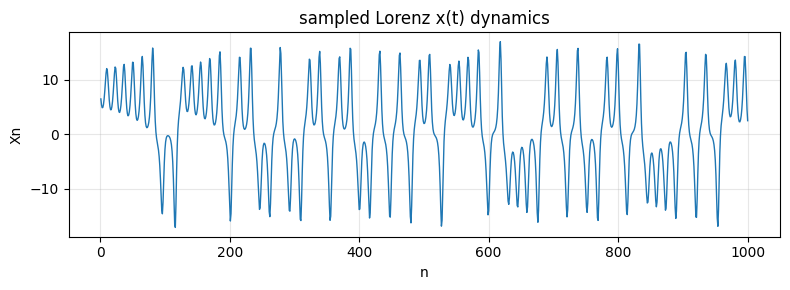

In [5]:
plt.figure(figsize=(8, 3))
plt.plot(np.arange(1, len(Xn) + 1), Xn, lw=1.0)
plt.xlabel('n')
plt.ylabel('Xn')
plt.title('sampled Lorenz x(t) dynamics')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2D delay embeddings
We will plot $X_n$ versus $X_{n-k}$ for $k \in \{1, 2, 4, 8\}$ to to discern any structure in the dynamics.

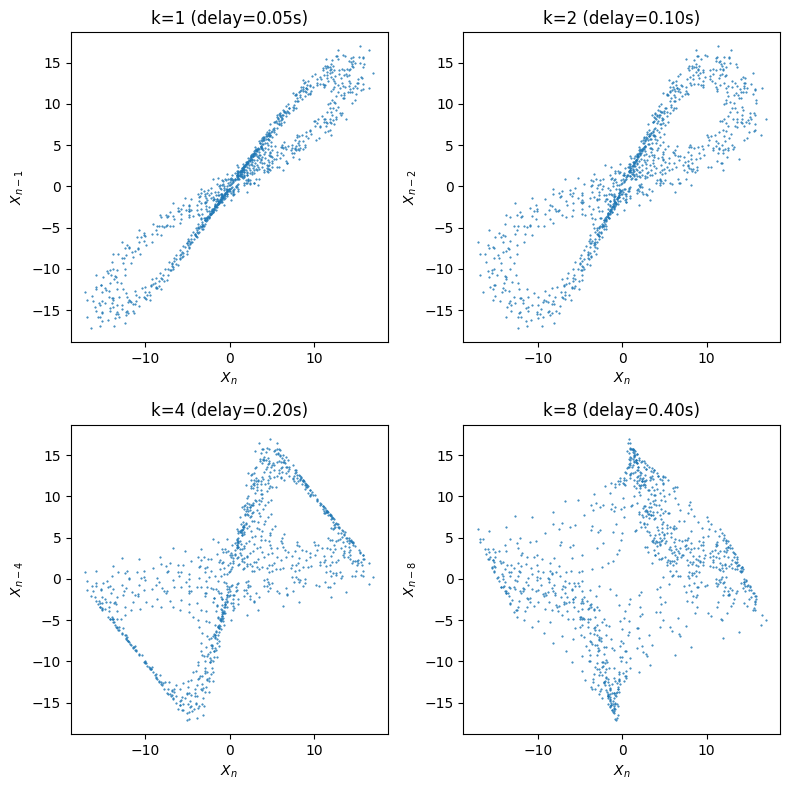

In [6]:
k_values = [1, 2, 4, 8]
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for ax, k in zip(axes.ravel(), k_values):
    ax.plot(Xn[:-k], Xn[k:], '.', markersize=1)
    ax.set_title(f'k={k} (delay={k*sample_dt:.2f}s)')
    ax.set_xlabel(r'$X_n$')
    ax.set_ylabel(fr'$X_{{n-{k}}}$')

plt.tight_layout()
plt.show()

The optimal value for $k$ would be the one that reconstructs the attractor topology without transforming it into noise or highly correlated sequences. For $k=2$ (corresponding to a delay of $0.1$ seconds), we see a good butterfly shape with its delay being lesser but close to the autocorrelation time, $\tau_c \approx 0.30$ s, from previous calculations. It is clear that a further delay, for instance with $k=8$, is distorting the inherent structure quite heavily.

### Phase-space plots
We use the numerical derivative to plot $\dot{x}$ versus $x$ to again discern structure in the recorded dynamics. As we can see below, this also reproduces a kind of a butterfly attractor that is similar to the full Lorenz system.

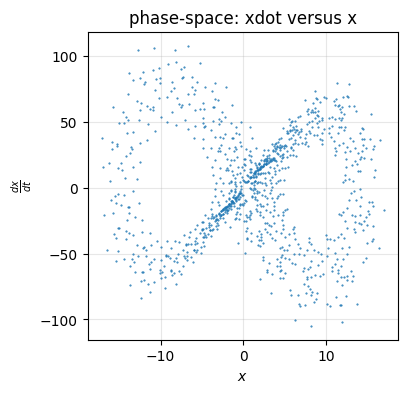

In [10]:
dx_dt = (Xn[2:] - Xn[:-2]) / (2 * sample_dt)
X_ctr = Xn[1:-1]

plt.figure(figsize=(4, 4))
plt.plot(X_ctr, dx_dt, '.', markersize=1)
plt.xlabel(r'$x$')
plt.ylabel(r'$\frac{dx}{dt}$')
plt.title('phase-space: xdot versus x')
plt.grid(alpha=0.3)
plt.show()

### Return map
We compute the local maxima of the trace to understand the oscillation structure in dynamics and approximate a kind of return map.

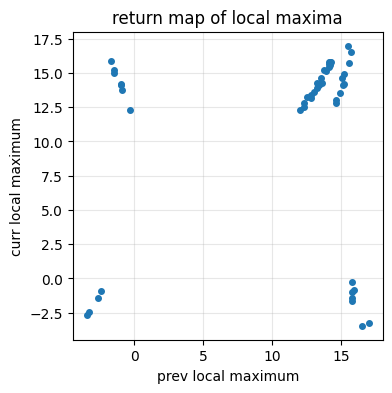

In [14]:
def local_maxima(x): # x being a subsection of x(t) part of the trajectory
    # interior points where x[i] > neighbors
    idx = np.where((x[1:-1] > x[:-2]) & (x[1:-1] > x[2:]))[0] + 1
    return x[idx]

peaks = local_maxima(Xn)
plt.figure(figsize=(4, 4))
plt.plot(peaks[:-1], peaks[1:], 'o', markersize=4)
plt.xlabel('prev local maximum')
plt.ylabel('curr local maximum')
plt.title('return map of local maxima')
plt.grid(alpha=0.3)
plt.show()

Despite the disjointed-ness in the four groups of points, the return map still seems to have a neat, close-to 1D structure to it (considering only the space/points spanned).

### 3D reconstruction
We use the 3D delay embeddings and 3D phase space to reconstruct the full attractor, and both of them capture the underlying 3D structure quite well, but the second derivative (for the phase space plot) already seems to be quite sensitive to discrete sampling and numerical errors (or noise).

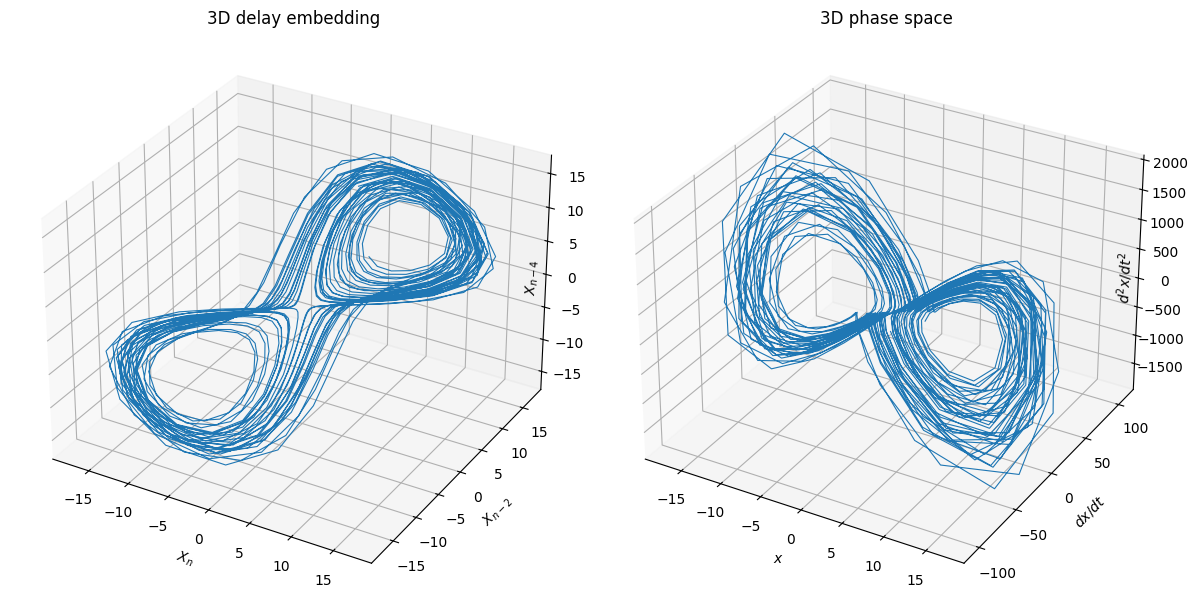

In [22]:
fig = plt.figure(figsize=(12, 6))

# 3D time delay embedding (using optimal k=2)
k = 2
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(Xn[2*k:], Xn[k:-k], Xn[:-2*k], lw=0.8)
ax1.set_title('3D delay embedding')
ax1.set_xlabel(r'$X_n$')
ax1.set_ylabel(fr'$X_{{n-{k}}}$')
ax1.set_zlabel(fr'$X_{{n-{2*k}}}$', labelpad=-27)

# 3D derivative embedding
d2x_dt2 = (Xn[2:] + Xn[:-2] - 2 * Xn[1:-1]) / (sample_dt**2)
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(X_ctr, dx_dt, d2x_dt2, lw=0.8)
ax2.set_title('3D phase space')
ax2.set_xlabel(r'$x$')
ax2.set_ylabel(r'$dx/dt$')
ax2.set_zlabel(r'$d^2x/dt^2$', labelpad=-27)

plt.tight_layout()
plt.show()